In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load of datasets


In [2]:
Titanic_df=pd.read_csv(r"/content/Titanic.csv")
Titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
Titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
Titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
Titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
Titanic_df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [7]:
Titanic_df['Age']=Titanic_df['Age'].fillna(Titanic_df['Age'].median())
Titanic_df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [8]:
Titanic_df['Cabin'].isnull().sum()

np.int64(687)

In [9]:
Titanic_df['Cabin'] = Titanic_df['Cabin'].fillna('Unknown')
# I filled the missing values in the Cabin column with 'Unknown' because the column contains a very
# high percentage of missing values (around 77%). Since Cabin is a categorical feature, replacing missing
# values with 'Unknown' preserves the information that the cabin details were not recorded. This allows me to
# retain the feature instead of losing potentially useful information by dropping the column.
Titanic_df['Cabin']

,Cabin
0,Unknown
1,C85
2,Unknown
3,C123
4,Unknown
...,...
886,Unknown
887,B42
888,Unknown
889,C148


# Ques 1 : Create a countplot to show the number of passengers by gender

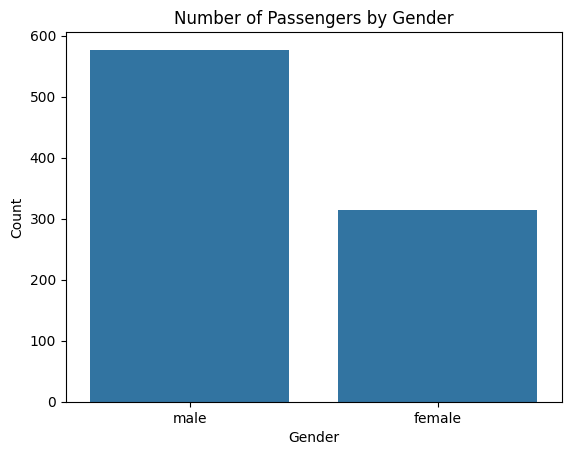

Interpretation
Male passengers = 577
Female passengers = 314
Males were significantly more than females 

 Insights :
The Titanic dataset contains nearly twice as many male passengers as female passengers



In [31]:
sns.countplot(x='Sex', data=Titanic_df)
plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
print("""Interpretation
Male passengers = 577
Female passengers = 314
Males were significantly more than females
""")
print(""" Insights :
The Titanic dataset contains nearly twice as many male passengers as female passengers
""" )

#  Ques 2: Create a bar chart to show the number of passengers in each passenger class using different colors.

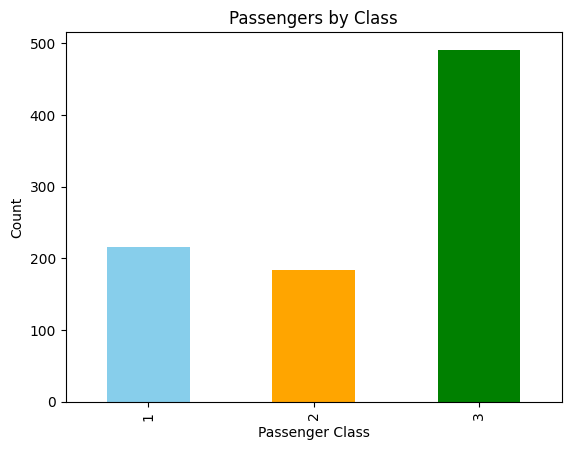

Interpretation
Passenger class 1 HAS COUNT : 216
Passengers class 2 has count : 184
Passenger class 3 has count : 491


iNSIGHTS :
Most passengers traveled in 3rd class, indicating that lower-class travel was the most common



In [32]:
Titanic_df['Pclass'].value_counts().sort_index().plot(
    kind='bar',
    color=['skyblue','orange','green']
)

plt.title('Passengers by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()
print("""Interpretation
Passenger class 1 HAS COUNT : 216
Passengers class 2 has count : 184
Passenger class 3 has count : 491

""")
print("""iNSIGHTS :
Most passengers traveled in 3rd class, indicating that lower-class travel was the most common
""")

# Ques 3: Create a histogram to show the distribution of passenger age.

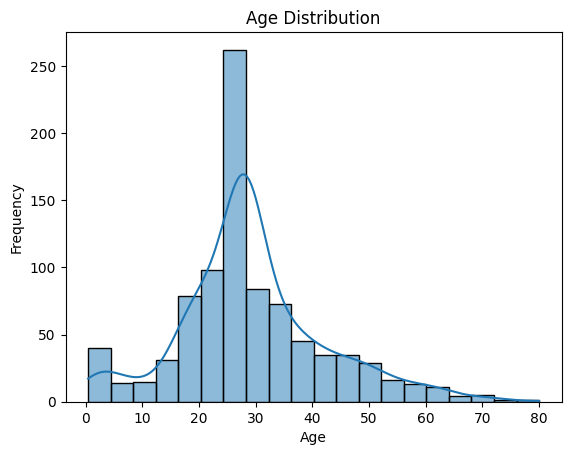

 Interpretation
Average Age approx 29.7 years
Most passengers were between 20–40 years old
Few passengers were above 60 years.

 Insights :
The Titanic passenger population was mainly composed of young adults



In [33]:
sns.histplot(Titanic_df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print(""" Interpretation
Average Age approx 29.7 years
Most passengers were between 20–40 years old
Few passengers were above 60 years.
""")
print(""" Insights :
The Titanic passenger population was mainly composed of young adults
""")

# Ques 4: Create a boxplot to detect outliers in the fare column

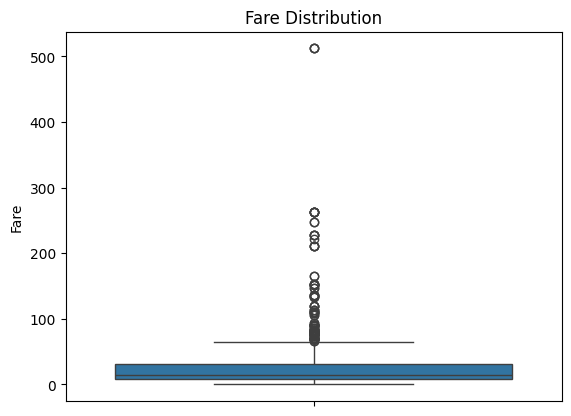

Interpretation
Many points appear above the upper whisker.
These points are fare outliers.
Some passengers paid exceptionally high ticket prices.

Insight
Fare distribution is highly skewed with several luxury ticket passengers paying much higher fares than average



In [34]:
sns.boxplot(y='Fare', data=Titanic_df)
plt.title('Fare Distribution')
plt.show()
print("""Interpretation
Many points appear above the upper whisker.
These points are fare outliers.
Some passengers paid exceptionally high ticket prices.
""")
print("""Insight
Fare distribution is highly skewed with several luxury ticket passengers paying much higher fares than average
""")

# Q5. Create a scatterplot to

 a. show the relationship between age and fare.

 b. analyze the relationship between family size (SibSp + Parch) and fare

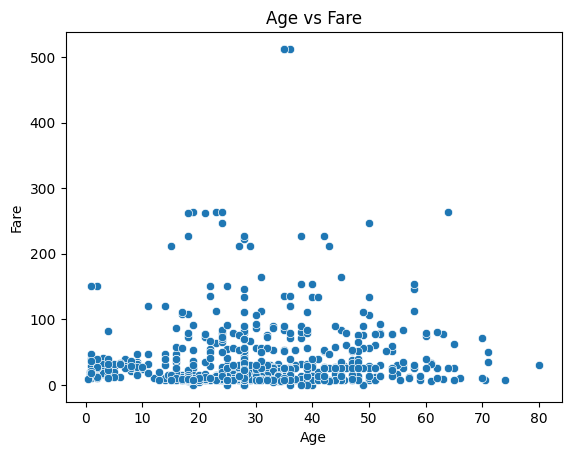

Interpretation
No strong linear relationship exists.
High fares were paid by passengers of different ages

Insight
Age does not strongly influence ticket fare



In [35]:
# Ans a
sns.scatterplot(x='Age', y='Fare', data=Titanic_df)
plt.title('Age vs Fare')
plt.show()

print("""Interpretation
No strong linear relationship exists.
High fares were paid by passengers of different ages
""")
print("""Insight
Age does not strongly influence ticket fare
""")

In [16]:
Titanic_df['FamilySize'] = Titanic_df['SibSp'] + Titanic_df['Parch']
Titanic_df['FamilySize']

,FamilySize
0,1
1,1
2,0
3,1
4,0
...,...
886,0
887,0
888,3
889,0


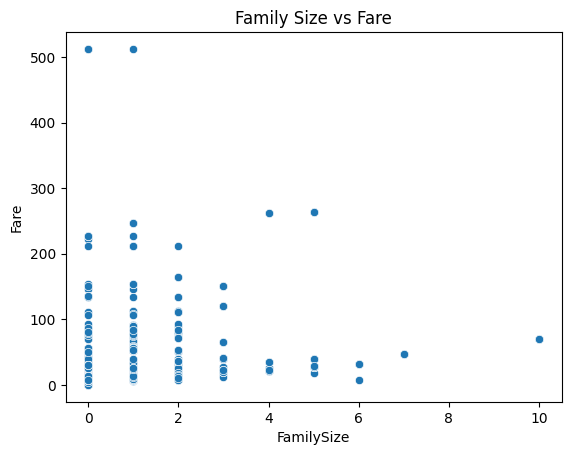

Interpretation
Passengers traveling with larger families often paid higher fares.
Relationship exists but is not very strong

Insight
Family size has a slight positive relationship with fare



In [37]:
# Ans 5b
sns.scatterplot(x='FamilySize', y='Fare', data=Titanic_df)
plt.title('Family Size vs Fare')
plt.show()

print("""Interpretation
Passengers traveling with larger families often paid higher fares.
Relationship exists but is not very strong
""")
print("""Insight
Family size has a slight positive relationship with fare
""")

#Ques 6 :Create a countplot to show survival count by gender

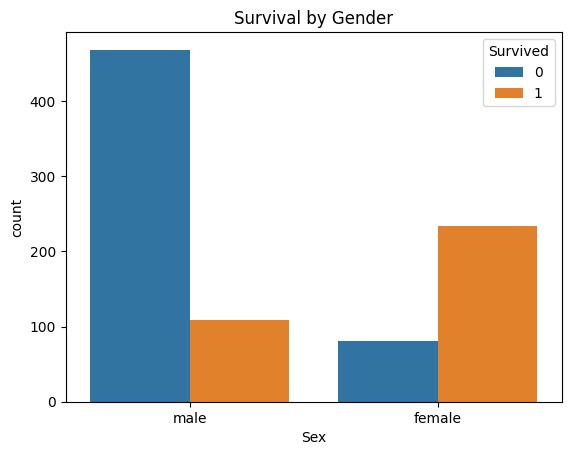


Interpretation
Female survived : 233	not survived : 81
Male	survived :109	not survived : 468

Insight
Females had a much higher survival rate than males



In [38]:
sns.countplot(x='Sex', hue='Survived', data=Titanic_df)
plt.title('Survival by Gender')
plt.show()
print("""
Interpretation
Female survived : 233	not survived : 81
Male	survived :109	not survived : 468
""")
print("""Insight
Females had a much higher survival rate than males
""")

# Ques 7 Create a bar chart to show survival by passenger class

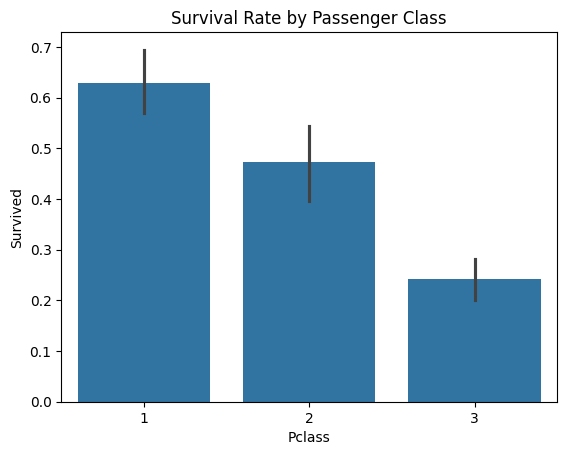

 Interpretation
Class 1 passengers survived most often.
Class 3 passengers had the lowest survival chances
 Insight
Passenger class had a strong impact on survival 


In [21]:
sns.barplot(x='Pclass', y='Survived', data=Titanic_df)
plt.title('Survival Rate by Passenger Class')
plt.show()

print(""" Interpretation
Class 1 passengers survived most often.
Class 3 passengers had the lowest survival chances""")
print(""" Insight
Passenger class had a strong impact on survival """)

## Q8. Create a heatmap to show correlation between numerical variables.

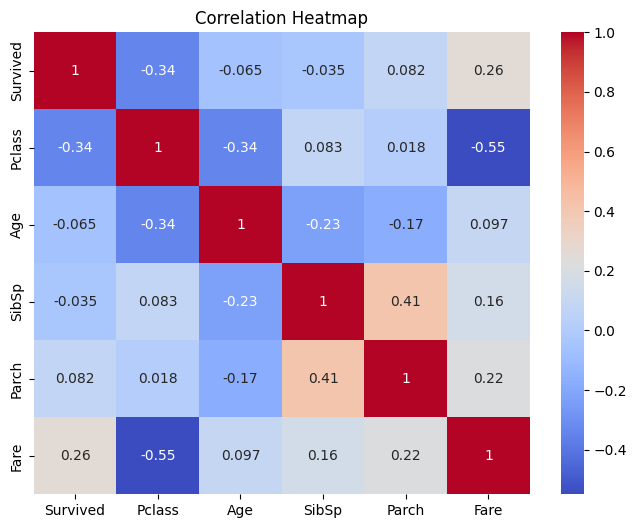

 Interpretation
Higher fare passengers were usually in higher classes.
Higher class passengers survived more often.
Family-related columns show moderate correlation.



In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(
    Titanic_df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

print(""" Interpretation
Higher fare passengers were usually in higher classes.
Higher class passengers survived more often.
Family-related columns show moderate correlation.
""")

# Q9. Identify which passenger class paid the highest fare on average.

In [28]:
Passenger_Class_Fair=Titanic_df.groupby('Pclass')['Fare'].mean()
print(Passenger_Class_Fair)
print(""" Interpretation
Passenger Class 1 paid the highest average fare (84.15) """)
print(""" Insights
First-class passengers paid significantly more than passengers in other classes """)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
 Interpretation 
Passenger Class 1 paid the highest average fare (84.15) 
 Insights 
First-class passengers paid significantly more than passengers in other classes 


# Q10: Write at least 5 insights from the dataset based on your visualizations.

In [29]:
print(""" Insight 1

Most passengers traveled in 3rd class (491 passengers).

Insight 2

There were more male passengers (577) than female passengers (314).

Insight 3

Female passengers had a much higher survival rate than males.

Insight 4

First-class passengers had the highest survival probability (62.96%).

Insight 5

First-class passengers paid the highest average fare (84.15), while third-class passengers paid the lowest (13.68)
""" )

 Insight 1

Most passengers traveled in 3rd class (491 passengers).

Insight 2

There were more male passengers (577) than female passengers (314).

Insight 3

Female passengers had a much higher survival rate than males.

Insight 4

First-class passengers had the highest survival probability (62.96%).

Insight 5

First-class passengers paid the highest average fare (84.15), while third-class passengers paid the lowest (13.68)

